In [1]:
pip install casadi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.7 MB/s eta 0:00:00


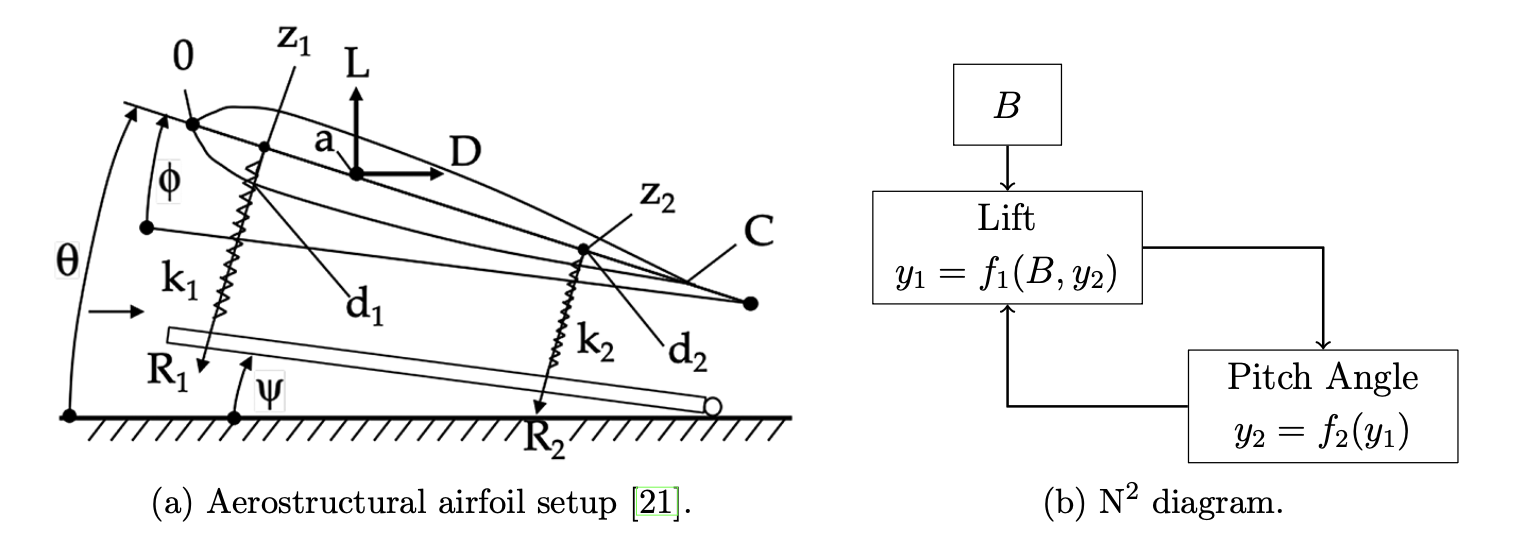

4.2 Aerostructures problem

The second example is adapted from Ghoreishi and Imani [21]. It represents an aerostructural system consisting of an elastically constrained lifting body in two-dimensional flow. A notional diagram is shown in Figure 6a. The two coupling variables are steady-state lift,

$$
y_1=L \in[0,300],
$$

and pitch angle,

$$
y_2=\phi \in[-\pi / 2, \pi / 2] .
$$


The scalar design variable $B \in[0,300)$ is the span of the lifting surface in centimeters.
The disciplinary equations are

$$
\begin{gathered}
L=f_1(\phi)=q B C\left(2 \pi(\phi+\psi)+r\left[1-\cos \left(\frac{\pi(\phi+\psi)}{2 \theta}\right)\right]\right), \\
\phi=f_2(L)=\left(\frac{L}{k_1(1+p)}-\frac{L p}{k_2(1+p)}\right) \frac{1}{C\left(z_2-z_1\right)} .
\end{gathered}
$$

The residuals are

$$
\begin{aligned}
& r_1=L-f_1(\phi) \\
& r_2=\phi-f_2(L)
\end{aligned}
$$


For this example, $n_0=8$ and $n_{\mathrm{AL}}=92$, giving 100 evaluations per residual and 200 total residual evaluations.



In [2]:
"""
CasADi translation of the OpenMDAO aerostructures benchmark.

Maps the original two-discipline OpenMDAO model:

    aerodynamicsDis : (B, phi) -> L
    structuresDis   : (L)      -> phi
    aerostructuresGroup : NonlinearBlockGS fixed-point coupling of the two
    Aerostructures.from_OpenMDAO : ScipyOptimizeDriver(COBYQA) optimization over B

onto CasADi equivalents:

    L_expr(B, phi)   : symbolic aero equation
    phi_expr(L)      : symbolic structures equation
    coupling solver  : ca.rootfinder (Newton) on the residual [r1; r2] = 0
                        -- this replaces NonlinearBlockGS, but unlike GS it is
                        exact-Newton rather than fixed-point-iteration, so it
                        will typically converge in far fewer iterations for the
                        same coupled system.
    outer optimizer  : ca.nlpsol (ipopt) over B
                        -- COBYQA is derivative-free; CasADi naturally gives you
                        exact derivatives via AD, so ipopt (gradient/Hessian-based)
                        is the natural replacement. If you need a literal
                        derivative-free driver, swap nlpsol for scipy.optimize on
                        top of the CasADi-evaluated coupling (see note at bottom).
"""

import casadi as ca
import numpy as np

# ---------------------------------------------------------------------------
# 1. Discipline equations (symbolic), matching aerodynamicsDis / structuresDis
# ---------------------------------------------------------------------------

def build_discipline_symbols():
    """Build symbolic CasADi expressions for the aero and structures equations."""

    B = ca.MX.sym("B")
    L = ca.MX.sym("L")
    phi = ca.MX.sym("phi")

    # --- aerodynamicsDis.compute --------------------------------------------
    q = 1.0       # N/cm^2
    C = 10.0      # cm
    psi = 0.05    # rad
    r = 0.9425
    theta0 = 0.26  # rad

    L_expr = (1.0 / 1000.0) * q * B * C * (
        (2.0 * np.pi * (phi + psi))
        + r * (1.0 - ca.cos(np.pi / 2.0 * (phi + psi) / theta0))
    )

    # --- structuresDis.compute ----------------------------------------------
    Cs = 10.0
    p = 0.1111
    k1 = 4000.0  # N/cm
    k2 = 2000.0  # N/cm
    z1 = 0.2
    z2 = 0.7

    # np.remainder(x, 2*pi) -> CasADi has no direct "remainder" primitive that
    # matches NumPy's floor-style remainder exactly, so we build it explicitly:
    # remainder(x, m) = x - m*floor(x/m)
    def remainder(x, m):
        return x - m * ca.floor(x / m)

    raw_phi = (
        (1000.0 * L / (k1 * (1.0 + p))) - (1000.0 * L * p) / (k2 * (1.0 + p))
    ) * (1.0 / (Cs * (z2 - z1)))
    phi_expr = remainder(raw_phi, 2.0 * np.pi)

    return B, L, phi, L_expr, phi_expr


B_sym, L_sym, phi_sym, L_expr, phi_expr = build_discipline_symbols()

# Standalone CasADi Functions for each discipline (useful on their own)
aero_fun = ca.Function("aero", [B_sym, phi_sym], [L_expr],
                       ["B", "phi"], ["L"])
struct_fun = ca.Function("struct", [L_sym], [phi_expr],
                         ["L"], ["phi"])


# ---------------------------------------------------------------------------
# 2. Coupling residuals r1, r2 (matches Aerostructures.r1 / r2 / res in torch)
# ---------------------------------------------------------------------------

def build_residuals():
    """Symbolic residuals r1 = L - L_expr(B,phi), r2 = phi - phi_expr(L)."""

    B = ca.MX.sym("B")
    L = ca.MX.sym("L")
    phi = ca.MX.sym("phi")

    _, _, _, L_expr_, phi_expr_ = (None, None, None, None, None)  # placeholder
    # Rebuild expressions in terms of these fresh symbols
    q, C, psi, r, theta0 = 1.0, 10.0, 0.05, 0.9425, 0.26
    L_of_B_phi = (1.0 / 1000.0) * q * B * C * (
        (2.0 * np.pi * (phi + psi)) + r * (1.0 - ca.cos(np.pi / 2.0 * (phi + psi) / theta0))
    )

    Cs, p, k1, k2, z1, z2 = 10.0, 0.1111, 4000.0, 2000.0, 0.2, 0.7
    raw_phi = ((1000.0 * L / (k1 * (1.0 + p))) - (1000.0 * L * p) / (k2 * (1.0 + p))) * (
        1.0 / (Cs * (z2 - z1))
    )
    phi_of_L = raw_phi - 2.0 * np.pi * ca.floor(raw_phi / (2.0 * np.pi))

    r1 = L - L_of_B_phi
    r2 = phi - phi_of_L
    res = ca.vertcat(r1, r2)

    return B, L, phi, r1, r2, res


B_r, L_r, phi_r, r1_expr, r2_expr, res_expr = build_residuals()

residual_fun = ca.Function("residual", [B_r, ca.vertcat(L_r, phi_r)], [res_expr],
                           ["B", "x_coupling"], ["res"])


# ---------------------------------------------------------------------------
# 3. Coupling solver: ca.rootfinder replacing NonlinearBlockGS
# ---------------------------------------------------------------------------
#
# OpenMDAO's `cycle` group ran NonlinearBlockGS (fixed-point Gauss-Seidel,
# maxiter=1000) to drive r1, r2 -> 0 for fixed B. ca.rootfinder with a Newton
# implementation solves the same residual system but via Newton iteration
# (exact, using AD-derived Jacobians), so it is the closest "solver-level"
# CasADi equivalent while typically converging much faster / more robustly.

_x_coupling = ca.MX.sym("x_coupling", 2)  # [L, phi]
_B_param = ca.MX.sym("B_param")

_rootfinder_residual = ca.Function(
    "mda_residual",
    [_x_coupling, _B_param],
    [residual_fun(_B_param, _x_coupling)],
)

mda_solver = ca.rootfinder(
    "mda_solver",
    "newton",
    _rootfinder_residual,
    {"error_on_fail": False},
)


def solve_mda(B_value: float, x0=(0.0, 0.0)) -> np.ndarray:
    """Solve the coupled aero-structures system for a given B.

    Equivalent to Aerostructures.from_OpenMDAO / running aerostructuresGroup's
    NonlinearBlockGS to convergence, but via Newton's method.

    Returns
    -------
    np.ndarray of shape (2,): [L, phi]
    """
    x0 = ca.DM(x0)
    sol = mda_solver(x0, B_value)
    return np.array(sol).flatten()


# ---------------------------------------------------------------------------
# 4. Outer optimization over B: ca.nlpsol replacing ScipyOptimizeDriver(COBYQA)
# ---------------------------------------------------------------------------
#
# The original driver only declares B as a design variable with bounds
# [0, 300] and no explicit objective/constraint is shown in the snippet
# (run_model() is called directly in from_OpenMDAO, not run_driver()), so the
# "optimization" in the source is really just an MDA evaluation harness.
# Below we expose both:
#   (a) mda_eval(B) -- direct analysis, mirrors from_OpenMDAO exactly
#   (b) optimize_B(objective) -- a genuine nlpsol-based outer optimization,
#       in case you do want to optimize something over B (e.g. minimize L,
#       or match a target L/phi). Swap the objective as needed.

def mda_eval(B_value: float, x0=(0.0, 0.0)) -> dict:
    """Direct equivalent of Aerostructures.from_OpenMDAO(B_value)."""
    L_val, phi_val = solve_mda(B_value, x0)
    return {"L": L_val, "phi": phi_val}


def optimize_B(objective="minimize_L", B_bounds=(0.0, 300.0), B0=150.0):
    """
    Outer optimization over B with the coupling solved inside the NLP via
    an embedded rootfinder call (so gradients flow through the MDA exactly,
    unlike COBYQA which is derivative-free and treats the MDA as a black box).

    objective: "minimize_L" or "minimize_phi" or a custom callable returning
               a CasADi expression of (L, phi, B).
    """
    B = ca.MX.sym("B")
    x_coupling = mda_solver(ca.DM([0.0, 0.0]), B)  # [L, phi], implicit function of B
    L_out, phi_out = x_coupling[0], x_coupling[1]

    if objective == "minimize_L":
        obj = L_out
    elif objective == "minimize_phi":
        obj = phi_out
    elif callable(objective):
        obj = objective(L_out, phi_out, B)
    else:
        raise ValueError("Unknown objective")

    nlp = {"x": B, "f": obj}
    opts = {"ipopt.print_level": 0, "print_time": False}
    solver = ca.nlpsol("solver", "ipopt", nlp, opts)

    sol = solver(x0=B0, lbx=B_bounds[0], ubx=B_bounds[1])
    B_opt = float(sol["x"])
    L_opt, phi_opt = solve_mda(B_opt)
    return {"B": B_opt, "L": L_opt, "phi": phi_opt, "f": float(sol["f"])}


if __name__ == "__main__":
    print("=== Discipline sanity check ===")
    print("aero(B=100, phi=0.1) ->", aero_fun(100.0, 0.1))
    print("struct(L=5.0) ->", struct_fun(5.0))

    print("\n=== MDA solve (replaces NonlinearBlockGS) for B=100 ===")
    result = mda_eval(100.0)
    print(result)
    print("residual check:", residual_fun(100.0, ca.DM([result["L"], result["phi"]])))

    print("\n=== Sweep over B (sanity vs a manual fixed-point GS) ===")
    for Bv in [0.0, 50.0, 100.0, 150.0, 200.0, 300.0]:
        r = mda_eval(Bv)
        print(f"B={Bv:6.1f}  L={r['L']:.6f}  phi={r['phi']:.6f}")

    print("\n=== Outer optimization over B (minimize L) ===")
    opt_res = optimize_B(objective="minimize_L")
    print(opt_res)

=== Discipline sanity check ===
aero(B=100, phi=0.1) -> 1.30372
struct(L=5.0) -> 0.175007

=== MDA solve (replaces NonlinearBlockGS) for B=100 ===
{'L': np.float64(0.5020129228182738), 'phi': np.float64(0.017571130022862636)}
residual check: [-3.41949e-14, 0]

=== Sweep over B (sanity vs a manual fixed-point GS) ===
B=   0.0  L=0.000000  phi=0.000000
B=  50.0  L=0.207870  phi=0.007276
B= 100.0  L=0.502013  phi=0.017571
B= 150.0  L=0.968472  phi=0.033898
B= 200.0  L=1.939799  phi=0.067896
B= 300.0  L=17.059039  phi=0.597089

=== Outer optimization over B (minimize L) ===

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

{'B': 6.947179697433135e-07, 'L': np

Replication of results of Fig7

https://arxiv.org/pdf/2606.13245$0


=== Multistart summary ===
B=  0.029  n_roots=1  failed_starts=20/63  roots=[(np.float64(0.0001), np.float64(0.0))]  single_start_result=(np.float64(0.0001), np.float64(0.0))
B= 33.359  n_roots=1  failed_starts=2/63  roots=[(np.float64(0.1314), np.float64(0.0046))]  single_start_result=(np.float64(0.1314), np.float64(0.0046))
B= 66.689  n_roots=1  failed_starts=2/63  roots=[(np.float64(0.2938), np.float64(0.0103))]  single_start_result=(np.float64(0.2938), np.float64(0.0103))
B=100.019  n_roots=1  failed_starts=1/63  roots=[(np.float64(0.5022), np.float64(0.0176))]  single_start_result=(np.float64(0.5022), np.float64(0.0176))
B=133.349  n_roots=1  failed_starts=0/63  roots=[(np.float64(0.7838), np.float64(0.0274))]  single_start_result=(np.float64(0.7838), np.float64(0.0274))
B=166.680  n_roots=1  failed_starts=0/63  roots=[(np.float64(1.2), np.float64(0.042))]  single_start_result=(np.float64(1.2), np.float64(0.042))
B=200.010  n_roots=1  failed_starts=0/63  roots=[(np.float64(1.9401

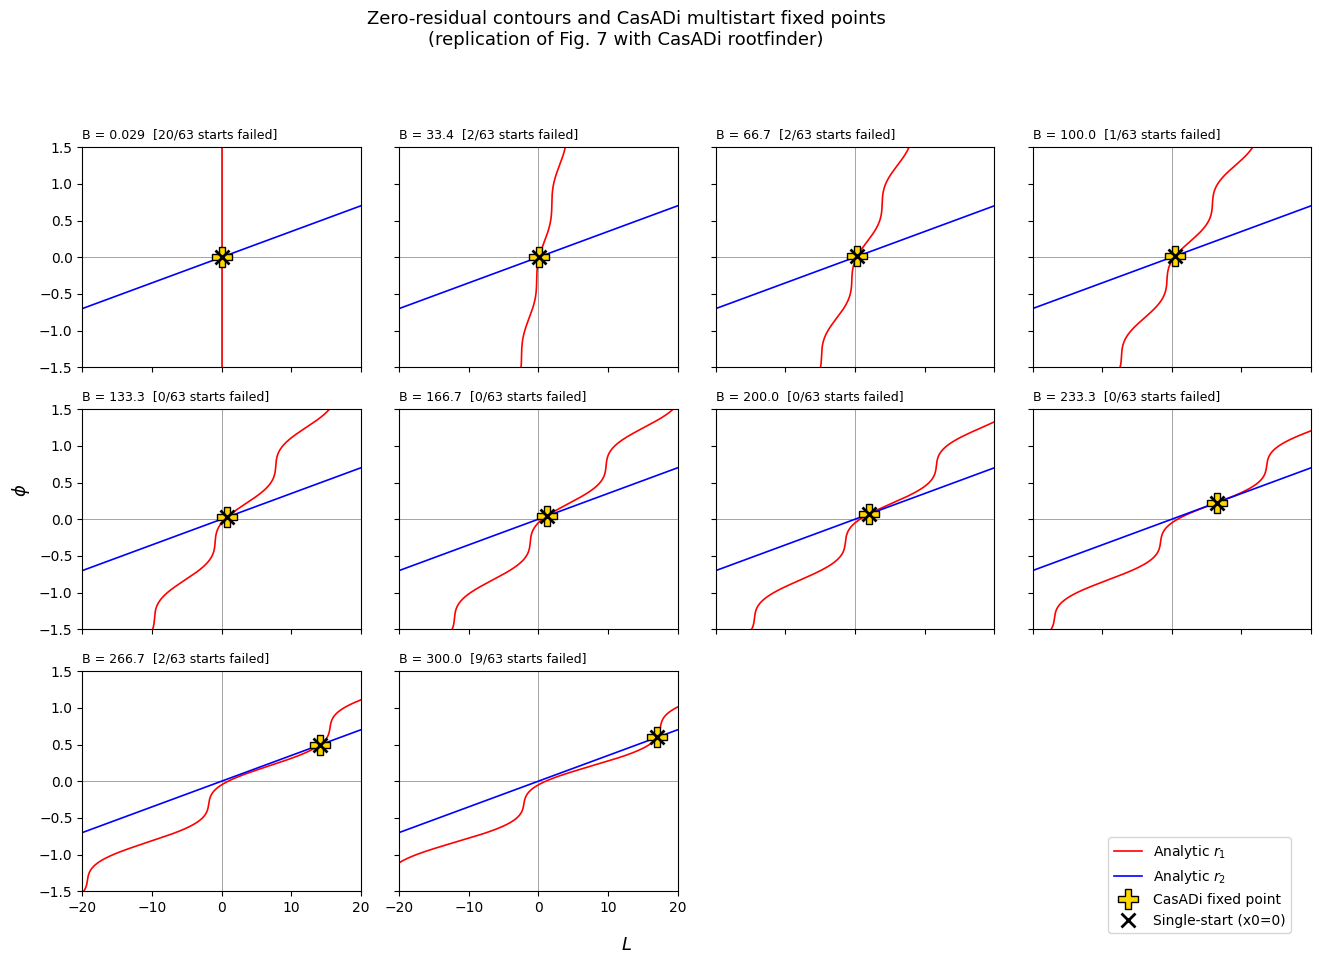

In [4]:
"""
Replicates the "zero-residual contour" figure (Fig. 7 style) for the
aerostructures benchmark, using the CasADi translation of the OpenMDAO model.

For each B:
  - r1(L, phi; B) = 0  -> solved analytically for L as a function of phi
                          (red curve), since r1 is linear in L:
                              L = num(phi) / [ (q*C/1000) * den(phi) ]
                          Wait: actually r1 = L - L_expr(B,phi), and L_expr is
                          LINEAR in B but not in L directly -- L_expr depends
                          only on B and phi, so r1=0 just means
                              L = L_expr(B, phi)
                          which is trivially a curve in (L, phi): sweep phi,
                          plot L = L_expr(B, phi).
  - r2(L, phi)    = 0  -> phi = phi_expr(L) is awkward to invert with the
                          remainder() wrap, so instead we sweep phi and solve
                          for L from r2=0 analytically (r2 is affine in L
                          before the wrap, so we invert it directly):
                              phi_unwrapped = raw_phi(L)  (affine in L)
                              => L = raw_phi^{-1}(phi + 2*pi*k) for integer k
                          We only need the principal branch matching the
                          plot's L in [-20, 20], so we invert the affine map
                          directly (no wrap needed within this range).
  - Multistart CasADi rootfinder (Newton) on the full 2D residual
    [r1; r2] = 0 from several initial guesses, to find ALL fixed points
    and confirm which one matches OpenMDAO / NonlinearBlockGS convergence.
"""

import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Discipline constants (identical to original)
# ---------------------------------------------------------------------------
q, C, psi, r_aero, theta0 = 1.0, 10.0, 0.05, 0.9425, 0.26
Cs, p, k1, k2, z1, z2 = 10.0, 0.1111, 4000.0, 2000.0, 0.2, 0.7


def L_of_B_phi(B, phi):
    """Aerodynamics: L as an explicit function of (B, phi). r1 = L - this."""
    return (1.0 / 1000.0) * q * B * C * (
        (2.0 * np.pi * (phi + psi)) + r_aero * (1.0 - np.cos(np.pi / 2.0 * (phi + psi) / theta0))
    )


def raw_phi_of_L(L):
    """Affine pre-wrap structures map: raw_phi = a*L (linear, no offset here)."""
    return (
        (1000.0 * L / (k1 * (1.0 + p))) - (1000.0 * L * p) / (k2 * (1.0 + p))
    ) * (1.0 / (Cs * (z2 - z1)))


def L_of_phi_from_r2(phi, k=0):
    """
    Invert r2 = phi - wrap(raw_phi(L)) = 0  =>  raw_phi(L) = phi + 2*pi*k.
    raw_phi(L) = a*L (purely linear, a = const), so:
        L = (phi + 2*pi*k) / a
    """
    a = ((1000.0 / (k1 * (1.0 + p))) - (1000.0 * p) / (k2 * (1.0 + p))) * (1.0 / (Cs * (z2 - z1)))
    return (phi + 2.0 * np.pi * k) / a


# ---------------------------------------------------------------------------
# CasADi symbolic residuals + rootfinder (same as aerostructures_casadi.py)
# ---------------------------------------------------------------------------
B_r = ca.MX.sym("B_r")
L_r = ca.MX.sym("L_r")
phi_r = ca.MX.sym("phi_r")

L_expr_sym = (1.0 / 1000.0) * q * B_r * C * (
    (2.0 * np.pi * (phi_r + psi)) + r_aero * (1.0 - ca.cos(np.pi / 2.0 * (phi_r + psi) / theta0))
)
raw_phi_sym = (
    (1000.0 * L_r / (k1 * (1.0 + p))) - (1000.0 * L_r * p) / (k2 * (1.0 + p))
) * (1.0 / (Cs * (z2 - z1)))
phi_expr_sym = raw_phi_sym - 2.0 * np.pi * ca.floor(raw_phi_sym / (2.0 * np.pi))

r1_sym = L_r - L_expr_sym
r2_sym = phi_r - phi_expr_sym
res_sym = ca.vertcat(r1_sym, r2_sym)

x_coupling = ca.MX.sym("x_coupling", 2)  # [L, phi]
res_sub = ca.substitute(res_sym, ca.vertcat(L_r, phi_r), x_coupling)
residual_fn = ca.Function("residual_fn", [x_coupling, B_r], [res_sub])

mda_solver = ca.rootfinder(
    "mda_solver", "newton", residual_fn, {"error_on_fail": False}
)


def multistart_solve(B_value, L_guesses=None, phi_guesses=None, tol=1e-6):
    """
    Multistart Newton solve of the coupled residual for a given B.

    Tries a grid of initial guesses, filters out NON-CONVERGED solves
    (Newton can stall near the floor()-induced discontinuity in the
    structures equation -- this is the actual failure mode multistart
    needs to guard against, not "multiple distinct roots": the system
    only has one true fixed point per B in this model), and dedups the
    surviving converged roots.

    Returns (converged_roots, n_failed_starts).
    """
    if L_guesses is None:
        L_guesses = np.linspace(-20, 20, 9)
    if phi_guesses is None:
        phi_guesses = np.linspace(-1.5, 1.5, 7)

    roots = []
    n_failed = 0
    for L0 in L_guesses:
        for phi0 in phi_guesses:
            try:
                sol = mda_solver(ca.DM([L0, phi0]), B_value)
                sol_np = np.array(sol).flatten()
                res_check = np.array(residual_fn(sol, B_value)).flatten()
                converged = np.all(np.abs(res_check) < tol) and np.all(np.isfinite(sol_np))
                if not converged:
                    n_failed += 1
                    continue
                is_new = True
                for existing in roots:
                    if np.allclose(sol_np, existing, atol=1e-4):
                        is_new = False
                        break
                if is_new:
                    roots.append(sol_np)
            except Exception:
                n_failed += 1
                continue
    return roots, n_failed


def solve_mda_from_zero(B_value):
    """Standard single-start solve from (0,0), matching from_OpenMDAO behavior."""
    sol = mda_solver(ca.DM([0.0, 0.0]), B_value)
    return np.array(sol).flatten()


# ---------------------------------------------------------------------------
# Build the figure: replicate Fig. 7 layout (10 panels, 4x3 grid -> use same
# B values as the original: 10 points from ~0 to 300)
# ---------------------------------------------------------------------------
B_values = np.linspace(0.029, 300.0, 10)
# match the original's slightly irregular first value
B_values[0] = 0.029

phi_plot = np.linspace(-1.5, 1.5, 800)

fig, axes = plt.subplots(3, 4, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, Bv in enumerate(B_values):
    ax = axes_flat[i]

    # Analytic r1 = 0: L = L_of_B_phi(B, phi), sweep phi -> (L, phi) curve
    L_curve_r1 = L_of_B_phi(Bv, phi_plot)
    ax.plot(L_curve_r1, phi_plot, 'r-', linewidth=1.2, label='Analytic $r_1$')

    # Analytic r2 = 0: L = L_of_phi_from_r2(phi, k=0), sweep phi -> (L, phi) line
    L_curve_r2 = L_of_phi_from_r2(phi_plot, k=0)
    ax.plot(L_curve_r2, phi_plot, 'b-', linewidth=1.2, label='Analytic $r_2$')

    # Multistart CasADi solve -> converged fixed point(s), with failure count
    roots, n_failed = multistart_solve(Bv)
    for j, root in enumerate(roots):
        ax.plot(root[0], root[1], marker='P', markersize=14,
                markerfacecolor='gold', markeredgecolor='black',
                linestyle='None', label='CasADi fixed point' if j == 0 and i == 0 else None)

    # Single-start solve from (0,0), matching original from_OpenMDAO behavior
    single_root = solve_mda_from_zero(Bv)
    ax.plot(single_root[0], single_root[1], marker='x', markersize=10,
            color='black', markeredgewidth=2, linestyle='None',
            label='Single-start (x0=0)' if i == 0 else None)

    n_starts = 9 * 7
    ax.set_title(
        (f"B = {Bv:.3f}" if Bv < 1 else f"B = {Bv:.1f}")
        + f"  [{n_failed}/{n_starts} starts failed]",
        loc='left', fontsize=9,
    )
    ax.set_xlim(-20, 20)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
    ax.axvline(0, color='gray', linewidth=0.5, zorder=0)

# hide unused panels (10 panels in a 3x4 grid -> 2 empty)
for k in range(len(B_values), len(axes_flat)):
    axes_flat[k].axis('off')

# shared labels
fig.text(0.5, 0.04, '$L$', ha='center', fontsize=13)
fig.text(0.06, 0.5, r'$\phi$', va='center', rotation='vertical', fontsize=13)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.05), fontsize=10)

fig.suptitle("Zero-residual contours and CasADi multistart fixed points\n"
             "(replication of Fig. 7 with CasADi rootfinder)", fontsize=13)

plt.tight_layout(rect=[0.07, 0.06, 1, 0.93])
# to this:
plt.savefig('replication_fig7.png', dpi=150)


# ---------------------------------------------------------------------------
# Print numeric summary: how many distinct fixed points per B, and whether
# the single-start solve matches one of the multistart roots
# ---------------------------------------------------------------------------
print("\n=== Multistart summary ===")
n_starts = 9 * 7
for Bv in B_values:
    roots, n_failed = multistart_solve(Bv)
    single = solve_mda_from_zero(Bv)
    print(f"B={Bv:7.3f}  n_roots={len(roots)}  failed_starts={n_failed}/{n_starts}  "
          f"roots={[tuple(np.round(rt, 4)) for rt in roots]}  "
          f"single_start_result={tuple(np.round(single, 4))}")